<a href="https://colab.research.google.com/github/sonavk2/LLM_Inference/blob/main/phase5_tradeoffs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 5 — Analysis of tradeoffs

This notebook loads the JSONLs from Phases 1, 2, and 4 and synthesizes them into comparisons across model architecture, context length, batch size, and serving backend.

In [2]:
import os

REPO_URL = "https://github.com/sonavk2/LLM_Inference.git"
REPO_NAME = REPO_URL.rstrip("/").split("/")[-1].replace(".git", "")

if not os.path.exists(REPO_NAME):
    !git clone {REPO_URL}

%cd {REPO_NAME}
!git pull


Cloning into 'LLM_Inference'...
remote: Enumerating objects: 271, done.
remote: Counting objects: 100% (271/271), done.
remote: Compressing objects: 100% (213/213), done.
remote: Total 271 (delta 141), reused 138 (delta 53), pack-reused 0 (from 0)
Receiving objects: 100% (271/271), 1.97 MiB | 18.30 MiB/s, done.
Resolving deltas: 100% (141/141), done.
/content/LLM_Inference/LLM_Inference
Already up to date.


In [3]:
!git pull

Already up to date.


In [4]:
import json, glob
from pathlib import Path
import pandas as pd

def load_files(pattern, backend_label, phase_label):
    rows = []
    for path in sorted(glob.glob(pattern)):
        for line in open(path):
            r = json.loads(line)
            r['_source'] = Path(path).name
            r['_backend'] = backend_label
            r['_phase']   = phase_label
            rows.append(r)
    return rows

rows = []
rows += load_files('../results/phase1_llama31_*.jsonl',  'HF (baseline)', 'phase1')
rows += load_files('../results/phase1_qwen3_*.jsonl',    'HF (baseline)', 'phase1')
rows += load_files('../results/phase1_qwen2vl_*.jsonl',  'HF VLM',         'phase1')
rows += load_files('../results/phase2_llama31_*.jsonl',  'HF (baseline)', 'phase2')
rows += load_files('../results/phase4_llama31_*.jsonl',  'vLLM',           'phase4')

df = pd.DataFrame(rows)

def short_model(name):
    if 'Llama-3.1' in name: return 'Llama-3.1-8B'
    if 'Qwen3'    in name: return 'Qwen3-8B'
    if 'Qwen2-VL' in name: return 'Qwen2-VL-7B'
    return name
df['_model_short'] = df['model_name'].apply(short_model)

PLOT_DIR = Path('../results/plots'); PLOT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = Path('../results')

print(f'loaded {len(df)} rows from {df["_source"].nunique()} files')
df.groupby(['_phase', '_backend', '_model_short']).size().reset_index(name='rows')

loaded 46 rows from 5 files


,_phase,_backend,_model_short,rows
0,phase1,HF (baseline),Llama-3.1-8B,4
1,phase1,HF (baseline),Qwen3-8B,4
2,phase1,HF VLM,Qwen2-VL-7B,4
3,phase2,HF (baseline),Llama-3.1-8B,20
4,phase4,vLLM,Llama-3.1-8B,14


## Plot 1 — Architecture comparison (single-request, HF)

How do Llama-3.1, Qwen3, and Qwen2-VL compare on the same hardware and backend, varying only context length?

saved ../results/plots/phase5_architecture.png


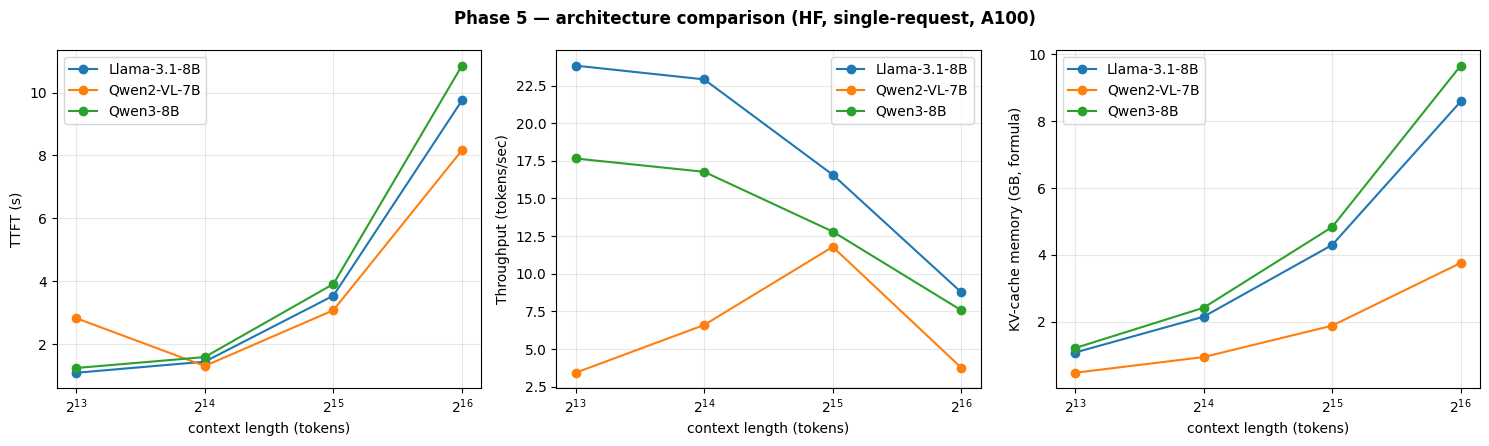

In [5]:
# 2. Architecture comparison: TTFT, throughput, KV-cache vs context. Single-request only, HF backend only.
import matplotlib.pyplot as plt

arch = df[(df._phase == 'phase1') & (df.batch_size == 1) & (df.success == True)].sort_values(['_model_short', 'context_length'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for col, ylabel, ax in [
    ('ttft_seconds',       'TTFT (s)',                     axes[0]),
    ('tokens_per_second',  'Throughput (tokens/sec)',      axes[1]),
    ('kv_cache_memory_gb', 'KV-cache memory (GB, formula)', axes[2]),
]:
    for model, grp in arch.groupby('_model_short'):
        ax.plot(grp.context_length, grp[col], marker='o', label=model)
    ax.set_xscale('log', base=2)
    ax.set_xlabel('context length (tokens)')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle('Phase 5 — architecture comparison (HF, single-request, A100)', fontsize=12, fontweight='bold')
plt.tight_layout()
out = PLOT_DIR / 'phase5_architecture.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()

## Plot 2 — HF vs vLLM, matched single-request cells (Llama-3.1)

Same model, same hardware, same context grid — the only thing changing is the serving backend. vLLM should win on decode throughput and total latency; TTFT improvement is smaller because prefill is compute-bound either way.

saved ../results/plots/phase5_backend_single.png


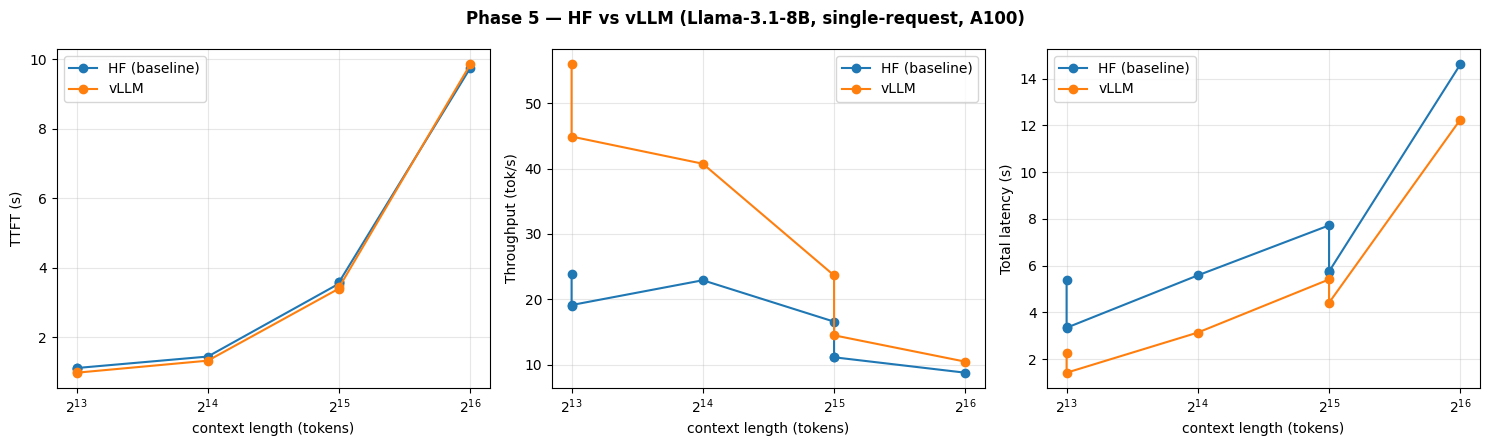

In [6]:
# 3. HF vs vLLM at matched single-request cells.
single_llama = df[(df._model_short == 'Llama-3.1-8B') & (df.batch_size == 1) & (df.success == True)]
single_llama = single_llama.sort_values(['_backend', 'context_length'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for col, ylabel, ax in [
    ('ttft_seconds',          'TTFT (s)',           axes[0]),
    ('tokens_per_second',     'Throughput (tok/s)', axes[1]),
    ('total_latency_seconds', 'Total latency (s)',  axes[2]),
]:
    for backend, grp in single_llama.groupby('_backend'):
        ax.plot(grp.context_length, grp[col], marker='o', label=backend)
    ax.set_xscale('log', base=2)
    ax.set_xlabel('context length (tokens)')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle('Phase 5 — HF vs vLLM (Llama-3.1-8B, single-request, A100)', fontsize=12, fontweight='bold')
plt.tight_layout()
out = PLOT_DIR / 'phase5_backend_single.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()

## Plot 3 — Throughput heatmap across (batch × context), HF vs vLLM

For each `(context, batch)` cell, the aggregate tokens/sec. White cells are runs that did not exist (HF) or did not succeed.

saved ../results/plots/phase5_throughput_heatmap.png


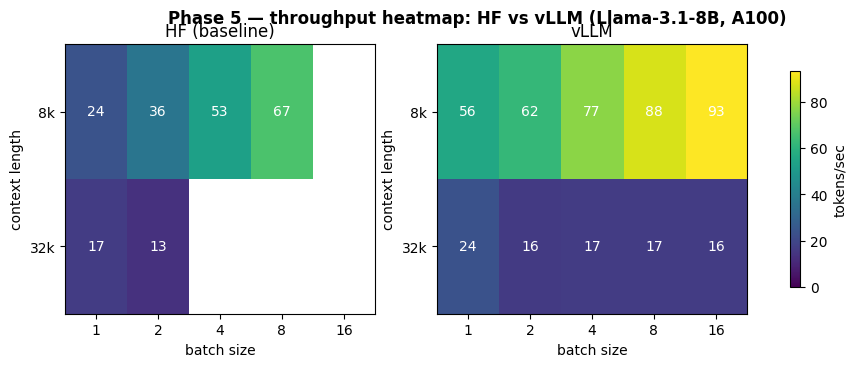

In [7]:
# 4. Throughput heatmap on the batch cells.
import numpy as np

batch_cells = df[(df._model_short == 'Llama-3.1-8B') &
                 df.context_length.isin([8192, 32768]) &
                 df.batch_size.isin([1, 2, 4, 8, 16])].copy()

backends = ['HF (baseline)', 'vLLM']
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
vmax = batch_cells[batch_cells.success == True].tokens_per_second.max()

for ax, backend in zip(axes, backends):
    sub = batch_cells[batch_cells._backend == backend]
    pivot = sub.pivot_table(index='context_length', columns='batch_size',
                            values='tokens_per_second', aggfunc='first')
    pivot_ok = sub[sub.success == True].pivot_table(index='context_length', columns='batch_size',
                                                    values='tokens_per_second', aggfunc='first')
    im = ax.imshow(pivot_ok.reindex(index=[8192, 32768], columns=[1,2,4,8,16]).values,
                   aspect='auto', cmap='viridis', vmin=0, vmax=vmax)
    for i, ctx in enumerate([8192, 32768]):
        for j, bsz in enumerate([1,2,4,8,16]):
            row = sub[(sub.context_length == ctx) & (sub.batch_size == bsz)]
            if len(row) == 0:
                txt = '–'
            elif not bool(row.iloc[0]['success']):
                txt = 'OOM'
            else:
                txt = f"{row.iloc[0]['tokens_per_second']:.0f}"
            ax.text(j, i, txt, ha='center', va='center', color='white', fontsize=10)
    ax.set_xticks(range(5)); ax.set_xticklabels([1,2,4,8,16])
    ax.set_yticks(range(2)); ax.set_yticklabels(['8k', '32k'])
    ax.set_xlabel('batch size'); ax.set_ylabel('context length')
    ax.set_title(backend)
fig.colorbar(im, ax=axes, label='tokens/sec', shrink=0.8)
fig.suptitle('Phase 5 — throughput heatmap: HF vs vLLM (Llama-3.1-8B, A100)', fontsize=12, fontweight='bold')
out = PLOT_DIR / 'phase5_throughput_heatmap.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()

## Plot 4 — Feasibility frontier

Which `(context, batch)` cells succeed under each backend. HF’s OOM region is the area vLLM covers via PagedAttention.

saved ../results/plots/phase5_frontier.png


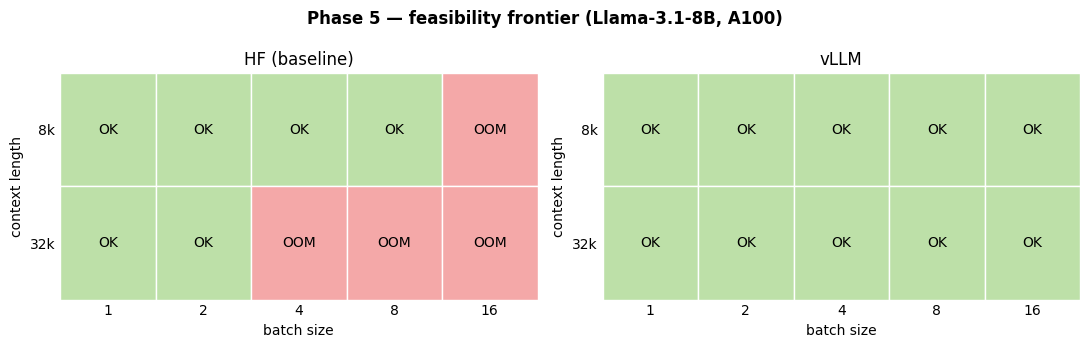

In [8]:
# 5. Feasibility frontier: OK / OOM grid for each backend.
from matplotlib.patches import Rectangle

frontier = batch_cells.copy()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for ax, backend in zip(axes, backends):
    sub = frontier[frontier._backend == backend]
    for i, ctx in enumerate([8192, 32768]):
        for j, bsz in enumerate([1, 2, 4, 8, 16]):
            row = sub[(sub.context_length == ctx) & (sub.batch_size == bsz)]
            if len(row) == 0:
                color, label = '#dddddd', '–'
            elif bool(row.iloc[0]['success']):
                color, label = '#bde0a8', 'OK'
            else:
                color, label = '#f4a8a8', 'OOM'
            ax.add_patch(Rectangle((j, i), 1, 1, facecolor=color, edgecolor='white'))
            ax.text(j + 0.5, i + 0.5, label, ha='center', va='center', fontsize=10)
    ax.set_xlim(0, 5); ax.set_ylim(0, 2); ax.invert_yaxis()
    ax.set_xticks(np.arange(5) + 0.5); ax.set_xticklabels([1,2,4,8,16])
    ax.set_yticks(np.arange(2) + 0.5); ax.set_yticklabels(['8k', '32k'])
    ax.set_xlabel('batch size'); ax.set_ylabel('context length')
    ax.set_title(backend)
    ax.tick_params(length=0)
    for spine in ax.spines.values(): spine.set_visible(False)

fig.suptitle('Phase 5 — feasibility frontier (Llama-3.1-8B, A100)', fontsize=12, fontweight='bold')
plt.tight_layout()
out = PLOT_DIR / 'phase5_frontier.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()

## Plot 5 — Throughput–latency Pareto across all configurations

Each point is one successful `(backend, context, batch)` cell on Llama-3.1-8B.

saved ../results/plots/phase5_pareto.png


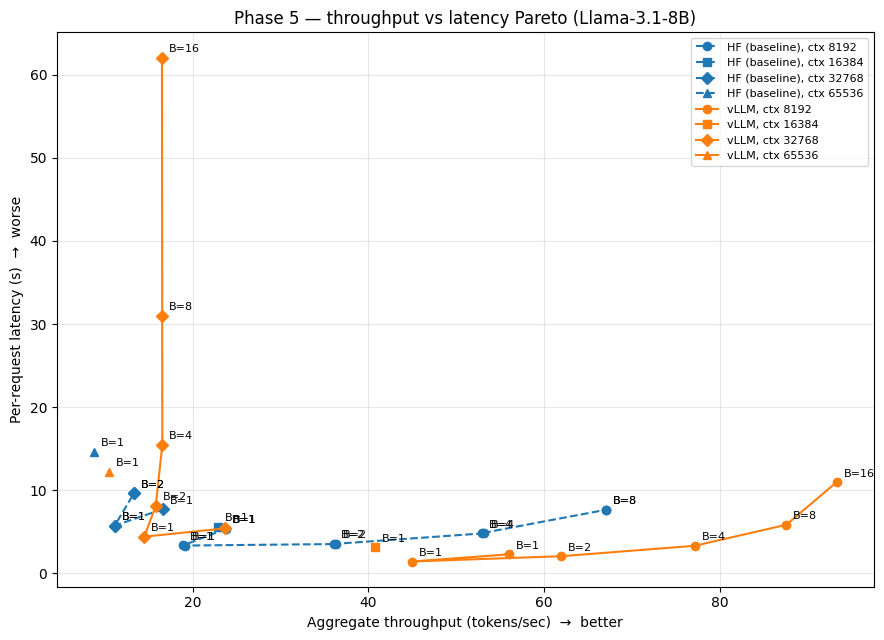

In [9]:
# 6. Pareto: throughput vs total latency for every successful Llama-3.1 cell, both backends.
ok = df[(df._model_short == 'Llama-3.1-8B') & (df.success == True)].copy()

fig, ax = plt.subplots(figsize=(9, 6.5))
markers = {8192: 'o', 16384: 's', 32768: 'D', 65536: '^'}
colors  = {'HF (baseline)': '#1f77b4', 'vLLM': '#ff7f0e'}

for backend, grp_b in ok.groupby('_backend'):
    for ctx, grp_c in grp_b.groupby('context_length'):
        grp_c = grp_c.sort_values('batch_size')
        ax.plot(grp_c.tokens_per_second, grp_c.total_latency_seconds,
                marker=markers.get(ctx, 'o'), color=colors[backend],
                linestyle='-' if backend == 'vLLM' else '--',
                label=f'{backend}, ctx {ctx}')
        for _, r in grp_c.iterrows():
            ax.annotate(f"B={int(r.batch_size)}",
                        (r.tokens_per_second, r.total_latency_seconds),
                        textcoords='offset points', xytext=(5, 4), fontsize=8)

ax.set_xlabel('Aggregate throughput (tokens/sec)  →  better')
ax.set_ylabel('Per-request latency (s)  →  worse')
ax.set_title('Phase 5 — throughput vs latency Pareto (Llama-3.1-8B)')
ax.grid(alpha=0.3)
ax.legend(loc='best', fontsize=8)
plt.tight_layout()
out = PLOT_DIR / 'phase5_pareto.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()

## Best config per goal

Three points across all successful runs (any model, any backend):
- **Lowest TTFT**
- **Highest throughput**
- **Lowest KV-cache footprint per token of context** — memory-bound deployments.

Saved as `results/phase5_best_configs.csv`.

In [10]:
# 7. Best-config summary table.
ok_all = df[df.success == True].copy()
ok_all['kv_per_ktoken_mb'] = (ok_all.kv_cache_memory_gb * 1024) / (ok_all.context_length / 1024)

cols = ['_model_short', '_backend', 'context_length', 'batch_size',
        'ttft_seconds', 'tpot_seconds', 'tokens_per_second',
        'kv_cache_memory_gb', 'kv_per_ktoken_mb']

best_ttft       = ok_all.loc[ok_all.ttft_seconds.idxmin()][cols]
best_throughput = ok_all.loc[ok_all.tokens_per_second.idxmax()][cols]
best_kv         = ok_all.loc[ok_all.kv_per_ktoken_mb.idxmin()][cols]

summary = pd.DataFrame({
    'goal':            ['lowest TTFT', 'highest throughput', 'lowest KV/token'],
    'model':           [best_ttft._model_short, best_throughput._model_short, best_kv._model_short],
    'backend':         [best_ttft._backend, best_throughput._backend, best_kv._backend],
    'context':         [int(best_ttft.context_length), int(best_throughput.context_length), int(best_kv.context_length)],
    'batch':           [int(best_ttft.batch_size), int(best_throughput.batch_size), int(best_kv.batch_size)],
    'ttft_s':          [best_ttft.ttft_seconds, best_throughput.ttft_seconds, best_kv.ttft_seconds],
    'throughput_tps':  [best_ttft.tokens_per_second, best_throughput.tokens_per_second, best_kv.tokens_per_second],
    'kv_per_ktoken_mb':[best_ttft.kv_per_ktoken_mb, best_throughput.kv_per_ktoken_mb, best_kv.kv_per_ktoken_mb],
})

out_csv = RESULTS_DIR / 'phase5_best_configs.csv'
summary.to_csv(out_csv, index=False)
print(f'saved {out_csv}')
summary

saved ../results/phase5_best_configs.csv


,goal,model,backend,context,batch,ttft_s,throughput_tps,kv_per_ktoken_mb
0,lowest TTFT,Llama-3.1-8B,vLLM,8192,1,0.985199,44.900515,137.438953
1,highest throughput,Llama-3.1-8B,vLLM,8192,16,9.171689,93.278478,2199.023256
2,lowest KV/token,Qwen2-VL-7B,HF VLM,8192,1,2.832122,3.422386,60.129542
